# 02 — Model Training & Experiment Tracking
## Fraud Detection MLOps Platform

This notebook:
1. Loads the preprocessed train/test data
2. Handles class imbalance using SMOTE
3. Trains a Logistic Regression baseline
4. Trains an XGBoost model with hyperparameter tuning
5. Logs every experiment to MLflow (metrics, params, model artifacts)
6. Registers the best model to MLflow Model Registry
7. Saves the final model for the API to use

### Run MLflow UI in a separate terminal before starting:

---
### Imports & config

In [2]:
import pandas as pd
import numpy as np
import json
import warnings
import mlflow
import mlflow.sklearn
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score, recall_score
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings("ignore")

# Paths
PROCESSED_DIR = Path("../data/processed")
MODELS_DIR    = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

# MLflow experiment — all runs will group under this name
EXPERIMENT_NAME = "fraud-detection"
mlflow.set_tracking_uri("../mlruns")
mlflow.set_experiment(EXPERIMENT_NAME)

print("Imports done")
print(f"MLflow tracking at: ../mlruns")
print(f"Open http://localhost:5000 to see the UI")

Imports done
MLflow tracking at: ../mlruns
Open http://localhost:5000 to see the UI


---
## Step 1 — Load Processed Data

In [3]:
# Load the train/test splits saved by notebook 01
X_train = pd.read_csv(PROCESSED_DIR / "X_train.csv")
X_test  = pd.read_csv(PROCESSED_DIR / "X_test.csv")
y_train = pd.read_csv(PROCESSED_DIR / "y_train.csv").squeeze()  # squeeze to Series
y_test  = pd.read_csv(PROCESSED_DIR / "y_test.csv").squeeze()

# Load feature names
with open(PROCESSED_DIR / "feature_names.json") as f:
    FEATURES = json.load(f)

print(f"X_train: {X_train.shape}  |  Fraud: {y_train.sum()} ({y_train.mean()*100:.3f}%)")
print(f"X_test:  {X_test.shape}   |  Fraud: {y_test.sum()} ({y_test.mean()*100:.3f}%)")
print(f"\nFeatures: {FEATURES}")

X_train: (160000, 12)  |  Fraud: 474 (0.296%)
X_test:  (40000, 12)   |  Fraud: 119 (0.298%)

Features: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'type_encoded', 'orig_balance_diff', 'dest_balance_diff', 'orig_balance_zero', 'amount_to_balance_ratio', 'hour_of_day']


---
## Step 2 — Handle Class Imbalance with SMOTE

Fraud is only ~0.3% of data. A naive model would just predict "not fraud" always and be 99.7% accurate — useless.

**SMOTE** (Synthetic Minority Oversampling Technique) creates synthetic fraud examples so the model actually learns what fraud looks like.

In [4]:
# Apply SMOTE only to training data — never touch the test set
# After SMOTE, a 10:1 ratio is wanted (not full 50:50, which can be too aggressive)
fraud_count    = y_train.sum()
non_fraud_count = (y_train == 0).sum()
target_fraud   = int(non_fraud_count * 0.1)  # 10% fraud ratio after resampling

print(f"Before SMOTE — Fraud: {fraud_count:,}  |  Non-fraud: {non_fraud_count:,}")

smote = SMOTE(
    sampling_strategy={1: target_fraud},
    random_state=42,
    k_neighbors=5
)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"After  SMOTE — Fraud: {y_train_sm.sum():,}  |  Non-fraud: {(y_train_sm==0).sum():,}")
print(f"New fraud ratio: {y_train_sm.mean()*100:.1f}%")

Before SMOTE — Fraud: 474  |  Non-fraud: 159,526
After  SMOTE — Fraud: 15,952  |  Non-fraud: 159,526
New fraud ratio: 9.1%


---
## Step 3 — Helper: Evaluation Function

Reusable function that prints a full report and plots a confusion matrix.

In [5]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    """Print metrics and plot confusion matrix for a trained model."""
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    roc_auc   = roc_auc_score(y_test, y_proba)
    f1        = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall    = recall_score(y_test, y_pred)

    print(f"\n{'='*50}")
    print(f"  {model_name} — Evaluation Results")
    print(f"{'='*50}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=["Not Fraud", "Fraud"]))

    # Confusion matrix plot
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Not Fraud", "Fraud"],
                yticklabels=["Not Fraud", "Fraud"], ax=ax)
    ax.set_title(f"{model_name} — Confusion Matrix")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")
    plt.tight_layout()
    plt.show()

    return {"roc_auc": roc_auc, "f1": f1, "precision": precision, "recall": recall}

print("evaluate_model() ready")

evaluate_model() ready


---
## Step 4 — Baseline: Logistic Regression

Always start with a simple baseline. If XGBoost isn't much better, it's not worth the complexity.
Every run is logged to MLflow automatically.

Training Logistic Regression...
Done!

  Logistic Regression — Evaluation Results
  ROC-AUC:   0.9960
  F1 Score:  0.1915
  Precision: 0.1061
  Recall:    0.9832

              precision    recall  f1-score   support

   Not Fraud       1.00      0.98      0.99     39881
       Fraud       0.11      0.98      0.19       119

    accuracy                           0.98     40000
   macro avg       0.55      0.98      0.59     40000
weighted avg       1.00      0.98      0.99     40000



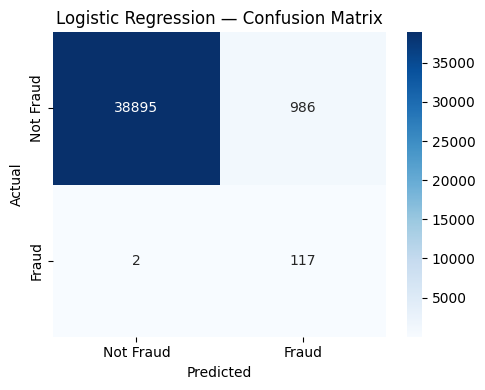

2026/05/28 19:17:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'FraudDetectionBaseline' already exists. Creating a new version of this model...
Created version '2' of model 'FraudDetectionBaseline'.



Logistic Regression run logged to MLflow


In [7]:
with mlflow.start_run(run_name="logistic_regression_baseline"):

    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("smote_ratio", 0.1)
    mlflow.log_param("C", 1.0)
    mlflow.log_param("max_iter", 1000)

    lr_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced",
                                      random_state=42, n_jobs=-1))
    ])

    print("Training Logistic Regression...")
    lr_pipeline.fit(X_train_sm, y_train_sm)
    print("Done!")

    lr_metrics = evaluate_model(lr_pipeline, X_test, y_test, "Logistic Regression")

    mlflow.log_metrics(lr_metrics)

    
    mlflow.sklearn.log_model(lr_pipeline, name="model",
                             registered_model_name="FraudDetectionBaseline")

    joblib.dump(lr_pipeline, MODELS_DIR / "logistic_regression.pkl")

    print("\nLogistic Regression run logged to MLflow")

---
## Step 5 — XGBoost Model

XGBoost handles imbalanced data well and typically outperforms logistic regression on tabular financial data.
We tune the key hyperparameters and log everything to MLflow.

In [8]:
# XGBoost hyperparameters — tuned for imbalanced fraud detection
XGB_PARAMS = {
    "n_estimators":     300,
    "max_depth":        6,
    "learning_rate":    0.05,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "scale_pos_weight": int((y_train == 0).sum() / y_train.sum()),  # handles imbalance
    "eval_metric":      "auc",
    "random_state":     42,
    "n_jobs":           -1
}

print("XGBoost hyperparameters:")
for k, v in XGB_PARAMS.items():
    print(f"  {k}: {v}")

XGBoost hyperparameters:
  n_estimators: 300
  max_depth: 6
  learning_rate: 0.05
  subsample: 0.8
  colsample_bytree: 0.8
  scale_pos_weight: 336
  eval_metric: auc
  random_state: 42
  n_jobs: -1


Training XGBoost (this takes ~1-2 minutes)...
[0]	validation_0-auc:0.99738
[50]	validation_0-auc:0.99328
[100]	validation_0-auc:0.99255
[150]	validation_0-auc:0.99224
[200]	validation_0-auc:0.99538
[250]	validation_0-auc:0.99583
[299]	validation_0-auc:0.99425
Done!

  XGBoost — Evaluation Results
  ROC-AUC:   0.9943
  F1 Score:  0.7945
  Precision: 0.6705
  Recall:    0.9748

              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00     39881
       Fraud       0.67      0.97      0.79       119

    accuracy                           1.00     40000
   macro avg       0.84      0.99      0.90     40000
weighted avg       1.00      1.00      1.00     40000



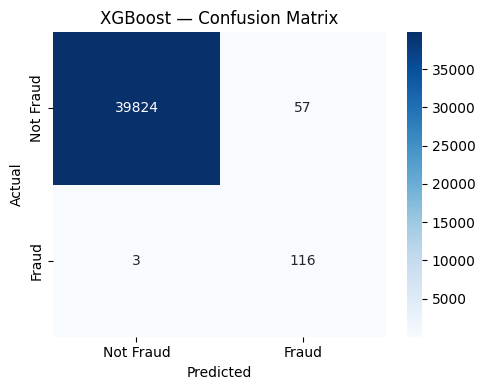

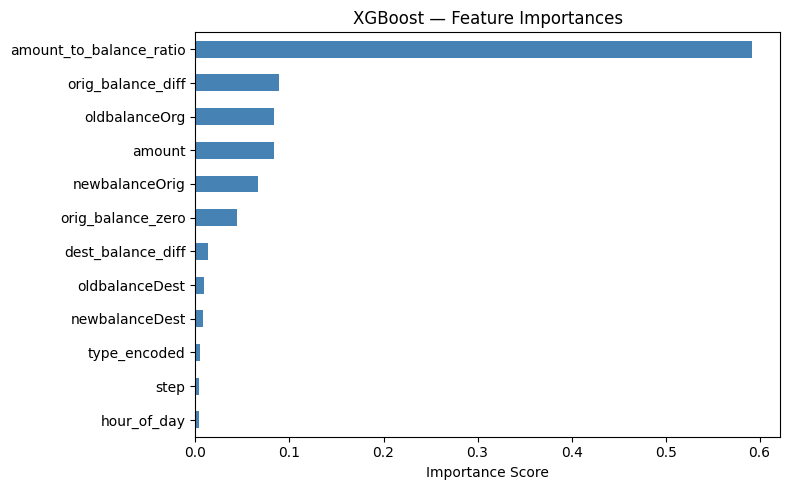

Successfully registered model 'FraudDetectionXGB'.
Created version '1' of model 'FraudDetectionXGB'.



XGBoost run logged to MLflow


In [9]:
with mlflow.start_run(run_name="xgboost_v1"):

    # Log all hyperparameters
    mlflow.log_params(XGB_PARAMS)
    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_param("smote_ratio", 0.1)

    xgb_model = XGBClassifier(**XGB_PARAMS)

    print("Training XGBoost (this takes ~1-2 minutes)...")
    xgb_model.fit(X_train_sm, y_train_sm,
                  eval_set=[(X_test, y_test)],
                  verbose=50)
    print("Done!")

    # Evaluate
    xgb_metrics = evaluate_model(xgb_model, X_test, y_test, "XGBoost")

    # Log metrics
    mlflow.log_metrics(xgb_metrics)

    # Feature importance plot — log as MLflow artifact
    fig, ax = plt.subplots(figsize=(8, 5))
    feat_imp = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values()
    feat_imp.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title("XGBoost — Feature Importances")
    ax.set_xlabel("Importance Score")
    plt.tight_layout()
    plt.savefig("../models/feature_importance.png")
    mlflow.log_artifact("../models/feature_importance.png")
    plt.show()

    # Log model to MLflow registry
    mlflow.xgboost.log_model(xgb_model, name="model",
                             registered_model_name="FraudDetectionXGB")

    # Save locally for the API
    joblib.dump(xgb_model, MODELS_DIR / "xgboost_model.pkl")

    print("\nXGBoost run logged to MLflow")

---
## Step 6 — Compare Both Models

Model Comparison:
                     roc_auc      f1  precision  recall
Logistic Regression   0.9960  0.1915     0.1061  0.9832
XGBoost               0.9943  0.7945     0.6705  0.9748


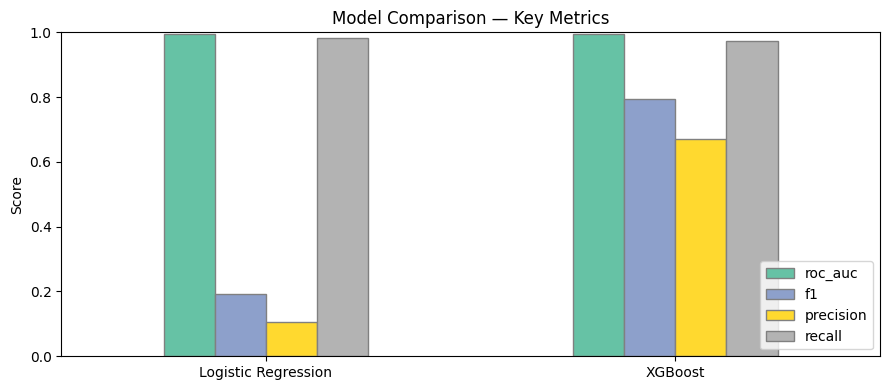


Best model by F1: XGBoost


In [10]:
# Side-by-side comparison of both models
results = pd.DataFrame({
    "Logistic Regression": lr_metrics,
    "XGBoost":             xgb_metrics
}).T

print("Model Comparison:")
print(results.round(4).to_string())

# Bar chart comparison
results[["roc_auc", "f1", "precision", "recall"]].plot(
    kind="bar", figsize=(9, 4), colormap="Set2", edgecolor="gray"
)
plt.title("Model Comparison — Key Metrics")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../models/model_comparison.png")
plt.show()

# Decide winner
best = "XGBoost" if xgb_metrics["f1"] > lr_metrics["f1"] else "Logistic Regression"
print(f"\nBest model by F1: {best}")

---
## Step 7 — Save Best Model for the API

The FastAPI app will load this file directly to serve predictions.

In [11]:
import shutil

# Copy the best model to a fixed filename the API always loads
best_model_path = MODELS_DIR / "best_model.pkl"

if best == "XGBoost":
    shutil.copy(MODELS_DIR / "xgboost_model.pkl", best_model_path)
else:
    shutil.copy(MODELS_DIR / "logistic_regression.pkl", best_model_path)

print(f"Best model saved -> {best_model_path}")
print(f"   The FastAPI app will load: models/best_model.pkl")

Best model saved -> ..\models\best_model.pkl
   The FastAPI app will load: models/best_model.pkl


---
## Summary

In [12]:
print("=" * 50)
print("TRAINING COMPLETE — SUMMARY")
print("=" * 50)
print(f"Experiment name:   {EXPERIMENT_NAME}")
print(f"Runs logged:       2  (logistic_regression_baseline, xgboost_v1)")
print(f"Best model:        {best}")
print(f"Best ROC-AUC:      {max(lr_metrics['roc_auc'], xgb_metrics['roc_auc']):.4f}")
print(f"Best F1:           {max(lr_metrics['f1'], xgb_metrics['f1']):.4f}")
print()
print("Saved files:")
for f in sorted(MODELS_DIR.glob("*")):
    print(f"   {f.name}")
print()
print("Next step -> open 03_drift_monitoring.ipynb")
print("View runs  -> http://localhost:5000")

TRAINING COMPLETE — SUMMARY
Experiment name:   fraud-detection
Runs logged:       2  (logistic_regression_baseline, xgboost_v1)
Best model:        XGBoost
Best ROC-AUC:      0.9960
Best F1:           0.7945

Saved files:
   best_model.pkl
   feature_importance.png
   logistic_regression.pkl
   model_comparison.png
   xgboost_model.pkl

Next step -> open 03_drift_monitoring.ipynb
View runs  -> http://localhost:5000


---
---
